# Part 1 — Data Loading and Understanding

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/hour.csv")

In [ ]:
print(f"Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes.head(10))
print("\nMissing Values:")
print(df.isnull().sum().sum())

Shape: (17379, 15)

Data Types:
instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
dtype: object

Missing Values:
0


In [ ]:
df["dteday"] = pd.to_datetime(df["dteday"])
df = df.sort_values(["dteday", "hr"]).reset_index(drop=True)

In [ ]:
target = "cnt"
leakage_cols = ["casual", "registered"]
df = df.drop(columns=leakage_cols)

In [ ]:
features = ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit",
            "temp", "atemp", "hum", "windspeed"]
X_raw = df[features]
y = df[[target]].values

# Part 2 — Train/Test Split

In [ ]:
n = len(df)
split_idx = int(0.8 * n)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Total samples : {n}")
print(f"Train samples: {len(X_train)}")
print(f"Test samples:  {len(X_test)}")

Total samples : 17379
Train samples: 13903
Test samples:  3476


A time-based split is safer for demand prediction because it ensures that the model is trained on only past information to predict future evemts. Having a random split would allow the model to see future patterns during training.

# Part 3 — Preprocessing

In [ ]:
cat_cols = ["season", "mnth", "hr", "weekday", "weathersit", "yr", "holiday", "workingday"]
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

In [ ]:
X = X.values.astype(float)

In [ ]:
print(f"Feature matrix shape after One-Hot Encoding: {X.shape}")

Feature matrix shape after One-Hot Encoding: (17379, 53)


# Part 4 — Implement Linear Regression (Normal Equation)

In [ ]:
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

print(f"Design matrix X_train_b shape: {X_train_b.shape}")
print(f"Design matrix X_test_b shape: {X_test_b.shape}")

# θ = (X_b^T X_b)^(-1) X_b^T y  OR  θ = X_b^+ y
theta = np.linalg.pinv(X_train_b) @ y_train

print(f"Theta shape: {theta.shape}")
print("Normal Equation weights calculated successfully.")

y_pred = X_test_b @ theta

Design matrix X_train_b shape: (13903, 54)
Design matrix X_test_b shape: (3476, 54)
Theta shape: (54, 1)
Normal Equation weights calculated successfully.


# Part 5 — Evaluation

MAE: 98.7976
RMSE: 133.8354
R2: 0.6315


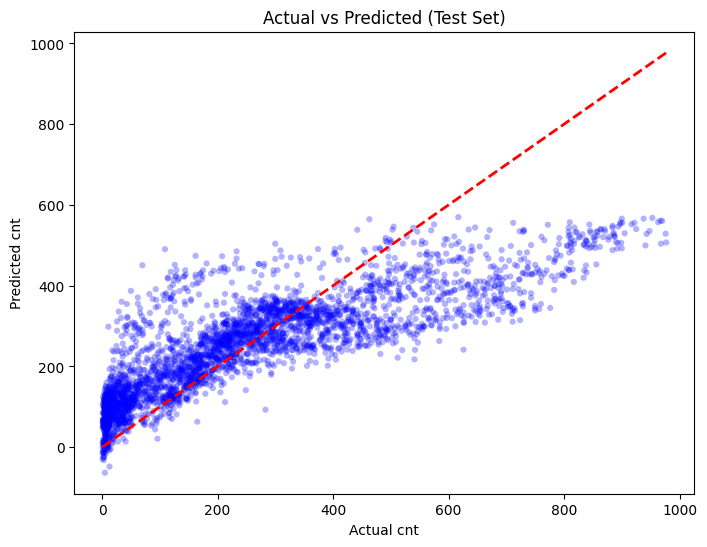

In [ ]:
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="blue", edgecolors="none", s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Actual vs Predicted (Test Set)")
plt.show()

# Part 6 — Compare with scikit-learn (sanity check)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_sk = mean_absolute_error(y_test, y_pred_sklearn)
rmse_sk = np.sqrt(mean_squared_error(y_test, y_pred_sklearn))
r2_sk = r2_score(y_test, y_pred_sklearn)

print(f"--- Scikit-Learn Metrics ---")
print(f"MAE:  {mae_sk:.4f}")
print(f"RMSE: {rmse_sk:.4f}")
print(f"R2:   {r2_sk:.4f}")

print(f"\nDifference in MAE: {abs(mae - mae_sk):.10f}")

--- Scikit-Learn Metrics ---
MAE:  98.7976
RMSE: 133.8354
R2:   0.6315

Difference in MAE: 0.0000000000


**Are they close? Why/why not?**

Yes, the metrics are virtually identical Both methods solve the same Ordinary Least Squares (OLS) problem to find the global minimum of the loss function. While our "from-scratch" model uses the Normal Equation ($\theta = (X^T X)^{-1} X^T y$) via a pseudoinverse, scikit-learn uses Singular Value Decomposition (SVD). Both paths lead to the same optimal weights for linear regression.

# Part 7 — Interpretation & Reflection

**Which 3 features appear most strongly associated with higher demand?**

The three features most strongly associated with higher bike demand are:

Temperature (temp) – Higher temperatures are associated with increased bike usage.

Hour of the day (hr) – Demand peaks during commuting hours (morning and evening).

Year (yr) – Demand increased in the second year, indicating growth in system usage.

**One potential limitation of linear regression for this problem.**

Assumption of Linearity: Linear regression assumes a straight-line relationship. In reality, demand is non-linear; for example, rentals might drop during extreme heat ($>95^{\circ}F$), a pattern a simple linear model cannot easily capture.

**One improvement you would try next.**
We would maybe implement a Random Forest or XGBoost model. These tree-based algorithms are much better at handling non-linear relationships and complex feature interactions (like the combined effect of rain and rush hour) without requiring extensive manual preprocessing.